# 13 — 15-Minute Living Circle Analysis (15分钟生活圈)

**Core question**: Within a 15-minute walk (800–1000 m), do residents have access
to the essential daily services (education, medical, shopping, green space, sports,
community services)? Which neighborhoods are inside a *walking* service radius, and
where are the service deserts?

**Three methods, increasing realism**:
1. **Euclidean buffer analysis** — crow-flies circles around residential areas.
2. **Network-based service area** — real walking distance along the street network
   (isochrones computed with `networkx` shortest paths).
3. **Facility accessibility scoring** — distance-decay weighted scores over a grid,
   with network walking distances, to rank every point in the study area.

**Standards referenced**:
- **TD/T 1062-2021** 《社区生活圈规划技术指南》 (Technical Guidelines for Community
  Life Circle Planning, Ministry of Natural Resources, effective 2022-01-01) —
  defines 15-min (800–1000 m), 10-min (500 m) and 5-min (300 m) urban community
  life circles and their facility configuration requirements.
- **GB 50180-2018** 《城市居住区规划设计标准》 — the tiered living circle system:
  居住街坊 → 五分钟生活圈居住区 (300 m) → 十分钟生活圈居住区 (500 m) →
  十五分钟生活圈居住区 (800–1000 m, roughly 1.3–2.0 km², 5–10 万人).

**Why it matters for Haidian (from the professional evaluation)**:
> The 15-minute living circle is a missing domain concept in the current tooling —
> HIGH priority. Facility *placement* (the "where") currently exists in the
> generation pipeline, but facility *coverage* (the "who is served") does not.

Walking speed assumption: 60 m/min planning standard → 300 m ≈ 5 min,
500 m ≈ 8–10 min, 800–1000 m ≈ 15 min.


## 0. Setup and Scenario

Synthetic district in local projected meters (as in notebooks 02–04, 10–11):
a ~2.4 km × 2.0 km residential district with a **river running N–S at x = 1400 m**,
crossable only at three bridges (y = 400, 800, 1600). The river creates real
street-network detours — the case where crow-flies distance overestimates true
walking accessibility.

- **Road network**: grid at 200 m spacing, routing nodes every 100 m; roads are
  cut at the river except at bridge locations.
- **Residential neighborhoods** R1–R10 placed at street intersections, west side
  dense (R1–R8), east side sparse (R9, R10) — R10 is the planned "service desert".
- **Facilities** (36 total) placed at street frontages, grouped by life-circle
  level (TD/T 1062-2021 basic-ensured 基础保障型):
  - Level 1 (5-min, 300 m): 社区便民服务站 community service (one per neighborhood),
    幼儿园 kindergarten
  - Level 2 (10-min, 500 m): 小学 primary school, 社区卫生服务站 clinic,
    公园绿地 park, 文体活动站 sports
  - Level 3 (15-min, 800–1000 m): 中学 middle school (1000 m), 社区医院 hospital
    (1000 m), 大型商业中心 mall (800 m), 养老设施 elderly care (800 m)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Polygon as MPLPolygon, Circle as MPLCircle
from shapely.geometry import Point, LineString, Polygon, box
from shapely.ops import unary_union
import networkx as nx
from dataclasses import dataclass, field
from typing import Dict, List, Tuple

# --- Chinese-capable font (same candidate list as src/visualization.py) ---
def _setup_chinese_font():
    for font in ["Heiti SC", "STHeiti", "Songti SC", "PingFang SC",
                 "Microsoft YaHei", "SimHei", "Arial Unicode MS"]:
        try:
            matplotlib.font_manager.findfont(font, fallback_to_default=False)
            plt.rcParams["font.sans-serif"] = [font, "DejaVu Sans"]
            plt.rcParams["axes.unicode_minus"] = False
            return font
        except Exception:
            continue
    plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    return "DejaVu Sans"

font_used = _setup_chinese_font()
import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # silence findfont warnings
print(f"Libraries loaded. Chinese font: {font_used} | numpy {np.__version__} | "
      f"networkx {nx.__version__}")


Libraries loaded. Chinese font: Heiti SC | numpy 2.3.5 | networkx 3.6.1


In [2]:
# =====================================================================
# Scenario: study area, river with bridges, road grid, facilities
# Local projected meters. River at x=1600 blocks roads except at bridges.
# =====================================================================

AREA = box(0, 0, 2400, 2000)
RIVER_X = 1400.0
BRIDGES = [(1400.0, 400.0), (1400.0, 800.0), (1400.0, 1600.0)]

# --- Road grid: vertical roads at x, horizontal roads at y (200 m spacing) ---
V_ROADS = [0.0, 200.0, 400.0, 600.0, 800.0, 1000.0, 1200.0, 1400.0,
           1600.0, 1800.0, 2000.0, 2200.0, 2400.0]
H_ROADS = [0.0, 200.0, 400.0, 600.0, 800.0, 1000.0, 1200.0, 1400.0,
           1600.0, 1800.0, 2000.0]
NODE_STEP = 100.0  # routing nodes every 100 m along each road

# --- Residential neighborhoods at street intersections (west dense,
#     north-east sparse -> the planned service desert R10) ---
RESIDENTIAL = {
    "R1":  (400, 400),  "R2":  (800, 400),  "R3": (1200, 400),
    "R4":  (400, 800),  "R5":  (800, 800),  "R6": (1200, 800),
    "R7":  (400, 1200), "R8":  (800, 1200), "R9": (2000, 800),
    "R10": (2000, 1200),
}

# --- Facilities: (name_zh, x, y, category, level, required_radius_m, weight) ---
# Weights reflect relative importance in TD/T 1062-2021 basic-ensured (基础保障型)
# Placements are hand-tuned so the west (R1-R8) is well served, the east bank
# (R9/R10) is under-served, and the east-bank sports facility at (1600,1000)
# is inside R6/R9/R10's Euclidean radius but outside their walking radius.
FACILITY_DEFS = [
    # Level 1 -- 5-min circle (300 m): one community station per neighborhood
    ("社区服务站", 400,  400, "community", 1, 300, 1.0),
    ("社区服务站", 800,  400, "community", 1, 300, 1.0),
    ("社区服务站", 1200, 400, "community", 1, 300, 1.0),
    ("社区服务站", 400,  800, "community", 1, 300, 1.0),
    ("社区服务站", 800,  800, "community", 1, 300, 1.0),
    ("社区服务站", 1200, 800, "community", 1, 300, 1.0),
    ("社区服务站", 400, 1200, "community", 1, 300, 1.0),
    ("社区服务站", 800, 1200, "community", 1, 300, 1.0),
    ("社区服务站", 2000, 800, "community", 1, 300, 1.0),   # east bank (R9)
    # Level 1 -- 幼儿园 (west side only)
    ("幼儿园", 400,  400, "kindergarten", 1, 300, 1.2),
    ("幼儿园", 800,  400, "kindergarten", 1, 300, 1.2),
    ("幼儿园", 1200, 400, "kindergarten", 1, 300, 1.2),
    ("幼儿园", 400,  800, "kindergarten", 1, 300, 1.2),
    ("幼儿园", 800,  800, "kindergarten", 1, 300, 1.2),
    ("幼儿园", 1200, 800, "kindergarten", 1, 300, 1.2),
    ("幼儿园", 400, 1200, "kindergarten", 1, 300, 1.2),
    ("幼儿园", 800, 1200, "kindergarten", 1, 300, 1.2),
    # Level 2 -- 10-min circle (500 m)
    ("小学", 800,  400, "school", 2, 500, 1.5),
    ("小学", 600,  800, "school", 2, 500, 1.5),
    ("小学", 1200, 800, "school", 2, 500, 1.5),
    ("小学", 1000, 1200, "school", 2, 500, 1.5),
    ("社区卫生服务站", 600,  600, "clinic", 2, 500, 1.4),
    ("社区卫生服务站", 1200, 600, "clinic", 2, 500, 1.4),
    ("社区卫生服务站", 600, 1200, "clinic", 2, 500, 1.4),
    ("公园绿地", 400,  400, "park", 2, 500, 1.0),
    ("公园绿地", 800,  800, "park", 2, 500, 1.0),
    ("公园绿地", 1200, 400, "park", 2, 500, 1.0),
    ("公园绿地", 2000, 600, "park", 2, 500, 1.0),          # east bank (R9)
    ("文体活动站", 800,  400, "sports", 2, 500, 0.8),
    ("文体活动站", 400,  800, "sports", 2, 500, 0.8),
    ("文体活动站", 1200, 1200, "sports", 2, 500, 0.8),
    ("文体活动站", 1600, 1000, "sports", 2, 500, 0.8),      # east bank -> detour trap
    # Level 3 -- 15-min circle (800 / 1000 m), district-scale single facilities
    ("中学", 800, 800, "middle_school", 3, 1000, 1.3),
    ("社区医院", 600, 800, "hospital", 3, 1000, 1.5),
    ("大型商业中心", 800, 600, "mall", 3, 800, 1.1),
    ("养老设施", 600, 600, "elderly", 3, 800, 1.2),
]

CATEGORY_COLORS = {
    "community": "#1d4ed8", "kindergarten": "#f59e0b", "school": "#059669",
    "clinic": "#dc2626", "park": "#16a34a", "sports": "#7c3aed",
    "middle_school": "#0d9488", "hospital": "#b91c1c", "mall": "#ea580c",
    "elderly": "#9333ea",
}
CATEGORY_LABELS = {
    "community": "社区服务站", "kindergarten": "幼儿园", "school": "小学",
    "clinic": "社区卫生服务站", "park": "公园绿地", "sports": "文体活动站",
    "middle_school": "中学", "hospital": "社区医院", "mall": "大型商业",
    "elderly": "养老设施",
}

facilities = [(name, Point(x, y), cat, lvl, rad, w)
              for name, x, y, cat, lvl, rad, w in FACILITY_DEFS]
res_points = {k: Point(xy) for k, xy in RESIDENTIAL.items()}

print(f"Study area: {AREA.bounds[2]} x {AREA.bounds[3]} m "
      f"({AREA.area/1e6:.2f} km²)")
print(f"River at x={RIVER_X:.0f} m, bridges at y = "
      + ", ".join(f"{b[1]:.0f}" for b in BRIDGES))
print(f"Residential neighborhoods: {len(res_points)} -> {list(res_points)}")
print(f"Facilities: {len(facilities)}")
for lvl in (1, 2, 3):
    n = sum(1 for f in facilities if f[3] == lvl)
    print(f"  Level {lvl} ({'5-min' if lvl==1 else '10-min' if lvl==2 else '15-min'} "
          f"circle): {n} facilities")


Study area: 2400.0 x 2000.0 m (4.80 km²)
River at x=1400 m, bridges at y = 400, 800, 1600
Residential neighborhoods: 10 -> ['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9', 'R10']
Facilities: 36
  Level 1 (5-min circle): 17 facilities
  Level 2 (10-min circle): 15 facilities
  Level 3 (15-min circle): 4 facilities


## 1. Method 1: Euclidean Buffer Analysis

The simplest evaluation: draw circles of radius 300 / 500 / 800–1000 m around each
residential point and count the facilities inside. A neighborhood is *covered* for
a category if at least one facility of that category falls inside the required radius.

**Limitation (to be quantified in Section 2)**: the circle assumes walking along
a straight line. A river, a rail line or a gated community turns a 400 m
crow-flies trip into a 1.5 km walk — the circle overstates coverage.


In [3]:
# =====================================================================
# Method 1: Euclidean buffers -- coverage per neighborhood and category
# =====================================================================

def euclidean_coverage(res_point: Point, facs: list, required_radius: float,
                       category: str) -> Tuple[bool, float]:
    """Is `category` covered within `required_radius` of `res_point`?
    Returns (covered, distance_to_nearest_in_category)."""
    d_min = np.inf
    for name, pt, cat, lvl, rad, w in facs:
        if cat == category:
            d_min = min(d_min, pt.distance(res_point))
    return (d_min <= required_radius, d_min)

categories = sorted({f[2] for f in facilities})
level_of_cat = {f[2]: f[3] for f in facilities}
radius_of_cat = {f[2]: f[4] for f in facilities}

# Coverage matrix: neighborhoods x categories
cov_matrix = {}
for rname, rpt in res_points.items():
    row = {}
    for cat in categories:
        covered, d_min = euclidean_coverage(rpt, facilities, radius_of_cat[cat], cat)
        row[cat] = covered
    cov_matrix[rname] = row

print(f"{'neighborhood':>12} | " + " | ".join(f"{c[:4]:>4}" for c in categories))
for rname in res_points:
    row = cov_matrix[rname]
    cells_s = " | ".join("   Y " if row[c] else "   . " for c in categories)
    print(f"{rname:>12} | {cells_s}")

# Coverage ratio: fraction of neighborhoods covered per category
print()
for lvl in (1, 2, 3):
    cats = [c for c in categories if level_of_cat[c] == lvl]
    covered = sum(all(cov_matrix[r][c] for c in cats) for r in res_points)
    print(f"Level {lvl} ({len(cats)} cats): {covered}/{len(res_points)} "
          f"neighborhoods fully covered "
          f"({100*covered/len(res_points):.0f}%)")

full = sum(all(row.values()) for row in cov_matrix.values())
print(f"\nAll categories covered (Euclidean): {full}/{len(res_points)} "
      f"neighborhoods ({100*full/len(res_points):.0f}%)")


neighborhood | clin | comm | elde | hosp | kind | mall | midd | park | scho | spor
          R1 |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y 
          R2 |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y 
          R3 |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y 
          R4 |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y 
          R5 |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y 
          R6 |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y 
          R7 |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    .  |    Y  |    Y 
          R8 |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y 
          R9 |    .  |    Y  |    .  |    .  |    .  |    .  |    .  |    Y  |    .  |    Y 
         R10 |    .  |    .  |    .  |    .  |    .  |    .  |    .  |    .  |  

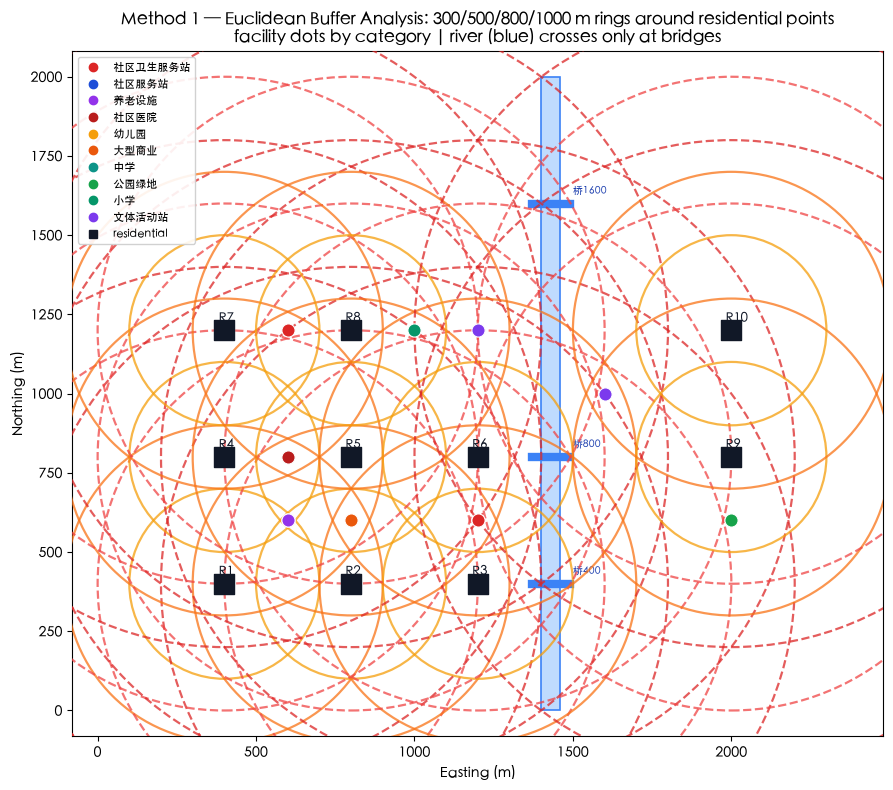

Saved ../outputs/13-buffer-map.png
Visual check: R10 at (2000,1200) sits in the north-east desert; the east-bank sports facility at (1600,1000) is inside its 500 m ring but requires a bridge detour on foot.


In [4]:
# ---------------------------------------------------------------------
# Figure 13.1: Euclidean buffer map -- rings vs facilities, river, bridges
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_aspect("equal")

# River
river_rect = MPLPolygon([(RIVER_X, 0), (RIVER_X, 2000), (RIVER_X + 60, 2000),
                         (RIVER_X + 60, 0)], closed=True, facecolor="#bfdbfe",
                        edgecolor="#3b82f6", lw=1.2, zorder=1)
ax.add_patch(river_rect)
for bx, by in BRIDGES:
    ax.plot([bx - 30, bx + 90], [by, by], color="#3b82f6", lw=6, zorder=2)
    ax.text(bx + 100, by + 30, f"桥{by:.0f}", fontsize=7, color="#1e40af")

# Buffer rings for every residential point (level radii)
for rname, rpt in res_points.items():
    for rad, col, ls in [(300, "#f59e0b", "-"), (500, "#f97316", "-"),
                         (800, "#ef4444", "--"), (1000, "#dc2626", "--")]:
        ring = MPLCircle((rpt.x, rpt.y), rad, fill=False, edgecolor=col,
                         lw=1.6, ls=ls, alpha=0.75, zorder=3)
        ax.add_patch(ring)

# Facilities by category
for name, pt, cat, lvl, rad, w in facilities:
    ax.scatter(pt.x, pt.y, s=90, color=CATEGORY_COLORS[cat], edgecolor="white",
               lw=0.8, zorder=5)
# Residential points
for rname, rpt in res_points.items():
    ax.scatter(rpt.x, rpt.y, s=210, marker="s", color="#111827", zorder=6)
    ax.text(rpt.x - 18, rpt.y + 25, rname, fontsize=9, fontweight="bold",
            color="#111827", zorder=7)

ax.set_xlim(-80, 2480); ax.set_ylim(-80, 2080)
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
ax.set_title("Method 1 — Euclidean Buffer Analysis: 300/500/800/1000 m rings "
             "around residential points\n"
             "facility dots by category | river (blue) crosses only at bridges",
             fontsize=12, fontweight="bold")

handles = [plt.Line2D([], [], marker="o", ls="", color=CATEGORY_COLORS[c],
                      label=CATEGORY_LABELS[c]) for c in categories]
handles += [plt.Line2D([], [], marker="s", ls="", color="#111827",
                       label="residential")]
ax.legend(handles=handles, loc="upper left", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig("../outputs/13-buffer-map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ../outputs/13-buffer-map.png")
r10 = res_points["R10"]
print(f"Visual check: R10 at ({r10.x:.0f},{r10.y:.0f}) sits in the north-east "
      f"desert; the east-bank sports facility at (1600,1000) is inside its "
      f"500 m ring but requires a bridge detour on foot.")


**Euclidean result preview**: the north-east corner (R10) is already suspect —
and the east-bank facilities (社区服务站 at (2000,800), 公园绿地 at (2000,600))
*are* inside R9's rings. The 文体活动站 at (1600,1000) even sits inside R6/R9/R10's
500 m ring. Are these really 10-minute walks? That depends on the bridges.
Method 2 answers it.

---

## 2. Method 2: Network-Based Service Area

Real walking is along streets, not straight lines. We build a graph of the street
network (nodes every 100 m, edge weight = length in meters, river segments removed
except at bridges) and compute **walking isochrones** with Dijkstra
(`nx.single_source_dijkstra_path_length`):

- **Service area polygon** = union of small discs around every graph node
  reachable within the radius.
- **Coverage test** = is the *network distance* to the nearest facility of a
  category ≤ required radius? (Facilities are snapped to the nearest node.)


In [5]:
# =====================================================================
# Build the walking network graph from the road grid + river constraints
# =====================================================================

G = nx.Graph()
bridge_ys = {b[1] for b in BRIDGES}

# Vertical roads at fixed x
for x in V_ROADS:
    ys = np.arange(0.0, 2000.0 + 1e-9, NODE_STEP)
    for i in range(len(ys) - 1):
        y1, y2 = ys[i], ys[i + 1]
        # segment crosses the river (x=1600)? blocked unless it is a bridge
        if abs(x - RIVER_X) < 1e-9 and not any(
                abs(y - by) < 1e-9 for y in (y1, y2) for by in bridge_ys):
            continue
        G.add_edge((x, y1), (x, y2), weight=abs(y2 - y1))
# Horizontal roads at fixed y: the node exactly on the river (x=RIVER_X)
# is removed unless y is a bridge row, so west-east crossings exist only
# at bridges.
for y in H_ROADS:
    xs = np.arange(0.0, 2400.0 + 1e-9, NODE_STEP)
    for i in range(len(xs) - 1):
        x1, x2 = xs[i], xs[i + 1]
        if y not in bridge_ys and (abs(x1 - RIVER_X) < 1e-9
                                   or abs(x2 - RIVER_X) < 1e-9):
            continue  # river crossing at non-bridge y -> no edge
        G.add_edge((x1, y), (x2, y), weight=abs(x2 - x1))

n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
n_components = nx.number_connected_components(G)
print(f"Graph: {n_nodes} nodes, {n_edges} edges, {n_components} connected "
      f"component(s)")

# Every network node must be able to route anywhere (bridges keep it connected)
# Sanity: can R1 reach R10 walking? (snap both to the nearest road node first)
def _nearest_node(x, y):
    return tuple(min(G.nodes, key=lambda n: (n[0] - x) ** 2 + (n[1] - y) ** 2))

d_sanity = nx.shortest_path_length(G, _nearest_node(400, 400),
                                   _nearest_node(2000, 1200), weight="weight")
d_eflat = Point(400, 400).distance(Point(2000, 1200))
print(f"R1 -> R10: walking {d_sanity:.0f} m vs crow-flies {d_eflat:.0f} m "
      f"(detour ratio {d_sanity/d_eflat:.2f})")


Graph: 393 nodes, 494 edges, 1 connected component(s)
R1 -> R10: walking 2400 m vs crow-flies 1789 m (detour ratio 1.34)


In [6]:
# =====================================================================
# Snap points to the graph, compute isochrones and network coverage
# =====================================================================

nodes = np.array(list(G.nodes))
node_pts = [Point(n) for n in G.nodes]

def snap(point: Point) -> Tuple[float, float]:
    """Nearest graph node to a point (brute force over ~1500 nodes is fine)."""
    d = np.array([point.distance(p) for p in node_pts])
    return tuple(nodes[int(np.argmin(d))])

def isochrone_nodes(source_pt: Point, radius: float) -> set:
    """All graph nodes within walking `radius` of `source_pt`."""
    src = snap(source_pt)
    lengths = nx.single_source_dijkstra_path_length(G, src, cutoff=radius,
                                                    weight="weight")
    return set(lengths.keys())

def network_dist(point_a: Point, point_b: Point) -> float:
    """Walking distance between two points (inf if unreachable)."""
    try:
        return nx.shortest_path_length(G, snap(point_a), snap(point_b),
                                       weight="weight")
    except nx.NetworkXNoPath:
        return np.inf

# Network coverage matrix
net_matrix = {}
for rname, rpt in res_points.items():
    row = {}
    for cat in categories:
        d_min = min(network_dist(rpt, pt) for name, pt, c2, l, r, w in facilities
                    if c2 == cat)
        row[cat] = (d_min <= radius_of_cat[cat], d_min)
    net_matrix[rname] = row

print(f"{'neighborhood':>12} | " + " | ".join(f"{c[:4]:>4}" for c in categories))
for rname in res_points:
    row = net_matrix[rname]
    cells_s = " | ".join("   Y " if row[c][0] else "   . " for c in categories)
    print(f"{rname:>12} | {cells_s}")

print()
for lvl in (1, 2, 3):
    cats = [c for c in categories if level_of_cat[c] == lvl]
    covered = sum(all(net_matrix[r][c][0] for c in cats) for r in res_points)
    print(f"Level {lvl}: {covered}/{len(res_points)} neighborhoods fully "
          f"covered ({100*covered/len(res_points):.0f}%)")

full_net = sum(all(row[c][0] for c in categories) for row in net_matrix.values())
print(f"\nAll categories covered (network): {full_net}/{len(res_points)} "
      f"({100*full_net/len(res_points):.0f}%)")


neighborhood | clin | comm | elde | hosp | kind | mall | midd | park | scho | spor
          R1 |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y 
          R2 |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y 
          R3 |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y 
          R4 |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y 
          R5 |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y 
          R6 |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y 
          R7 |    Y  |    Y  |    Y  |    Y  |    Y  |    .  |    Y  |    .  |    .  |    Y 
          R8 |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y  |    Y 
          R9 |    .  |    Y  |    .  |    .  |    .  |    .  |    .  |    Y  |    .  |    . 
         R10 |    .  |    .  |    .  |    .  |    .  |    .  |    .  |    .  |  

In [7]:
# ---------------------------------------------------------------------
# Quantify the gap: Euclidean vs network coverage, misclassifications
# ---------------------------------------------------------------------
print(f"{'neighborhood':>12} | {'Euclid':>6} {'Network':>7} | "
      f"{'false positive':>14}  example")
n_fp = 0
for rname in res_points:
    e = set(c for c in categories if cov_matrix[rname][c])
    n = set(c for c in categories if net_matrix[rname][c][0])
    fp = e - n          # Euclidean says covered, network says not
    fn = n - e          # network says covered, Euclidean says not
    n_fp += len(fp)
    example = (min(fp, key=lambda c: net_matrix[rname][c][1]) if fp else "-")
    d_ex = (net_matrix[rname][example][1] if fp else 0.0)
    print(f"{rname:>12} | {len(e):>6} {len(n):>7} | "
          f"{len(fp):>14}  {example if fp else '-'}"
          + (f" (walk {d_ex:.0f}m > {radius_of_cat[example]}m)" if fp else ""))

# Overall error rate
total_cells = len(res_points) * len(categories)
fp_total = sum(len(set(c for c in categories if cov_matrix[r][c])
                     - set(c for c in categories if net_matrix[r][c][0]))
               for r in res_points)
fn_total = sum(len(set(c for c in categories if net_matrix[r][c][0])
                     - set(c for c in categories if cov_matrix[r][c]))
               for r in res_points)
print(f"\nTotal category-neighborhood pairs: {total_cells}")
print(f"  Euclidean false positives (over-claims coverage): {fp_total} "
      f"({100*fp_total/total_cells:.1f}%)")
print(f"  Euclidean false negatives (misses real coverage): {fn_total} "
      f"({100*fn_total/total_cells:.1f}%)")


neighborhood | Euclid Network | false positive  example
          R1 |     10      10 |              0  -
          R2 |     10      10 |              0  -
          R3 |     10      10 |              0  -
          R4 |     10      10 |              0  -
          R5 |     10      10 |              0  -
          R6 |     10      10 |              0  -
          R7 |      9       7 |              2  school (walk 600m > 500m)
          R8 |     10      10 |              0  -
          R9 |      3       2 |              1  sports (walk 600m > 500m)
         R10 |      1       0 |              1  sports (walk 600m > 500m)

Total category-neighborhood pairs: 100
  Euclidean false positives (over-claims coverage): 4 (4.0%)
  Euclidean false negatives (misses real coverage): 0 (0.0%)


/var/folders/0w/hgj2rww17nb_x9q7pdkxh49r0000gn/T/ipykernel_25405/1709788021.py:38: UserWarning: You passed an edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(pt.x, pt.y, s=85, color=CATEGORY_COLORS[cat],


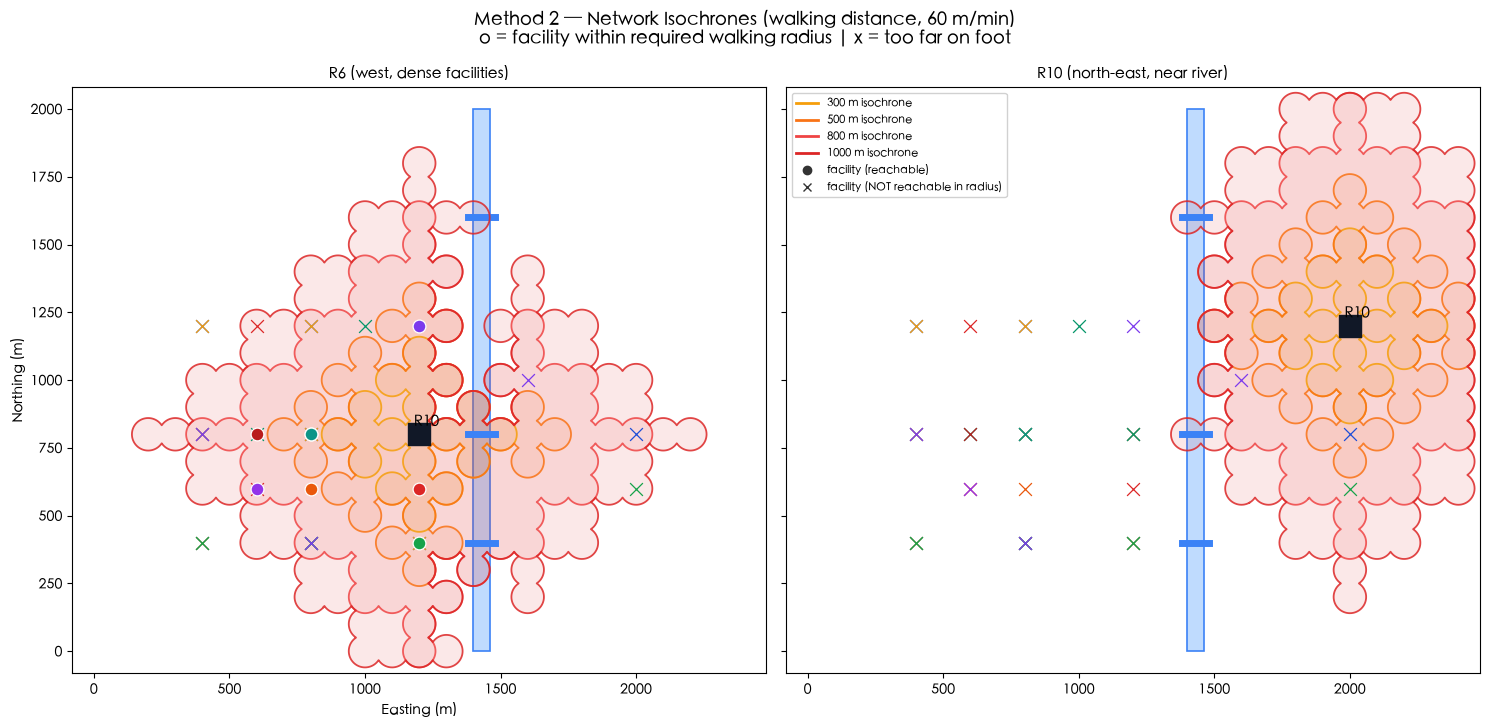

Saved ../outputs/13-network-isochrones.png
R6  -> east-bank sports (1600,1000): walk 900 m (crow-flies 447 m)
R10 -> east-bank sports (1600,1000): walk 700 m (crow-flies 447 m)


In [8]:
# ---------------------------------------------------------------------
# Figure 13.2: Network isochrones vs Euclidean rings for R6 and R10
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6.8), sharex=True, sharey=True)

for ax, rpt, title in [
    (axes[0], res_points["R6"], "R6 (west, dense facilities)"),
    (axes[1], res_points["R10"], "R10 (north-east, near river)"),
]:
    ax.set_aspect("equal")
    ax.add_patch(MPLPolygon([(RIVER_X, 0), (RIVER_X, 2000), (RIVER_X + 60, 2000),
                             (RIVER_X + 60, 0)], closed=True,
                            facecolor="#bfdbfe", edgecolor="#3b82f6", lw=1.2))
    for bx, by in BRIDGES:
        ax.plot([bx - 20, bx + 80], [by, by], color="#3b82f6", lw=5)

    # Network service areas (isochrones) as union of node discs.
    # Disc radius 60 m > half the 100 m node spacing, so the union is
    # connected along roads and traces the street pattern.
    for rad, col in [(300, "#f59e0b"), (500, "#f97316"), (800, "#ef4444"),
                     (1000, "#dc2626")]:
        reach = isochrone_nodes(rpt, rad)
        if reach:
            discs = [p.buffer(60) for p in node_pts
                     if tuple(p.coords[0]) in reach]
            blob = unary_union(discs)
            blobs = blob.geoms if blob.geom_type == "MultiPolygon" else [blob]
            for poly in blobs:
                ax.plot(*poly.exterior.xy, color=col, lw=1.3, alpha=0.85)
                ax.add_patch(MPLPolygon(list(poly.exterior.coords),
                                        closed=True, facecolor=col,
                                        alpha=0.10, edgecolor="none"))

    # Facilities colored by network reachability within its required radius
    for name, pt, cat, lvl, rad, w in facilities:
        d = network_dist(rpt, pt)
        ok = d <= rad
        ax.scatter(pt.x, pt.y, s=85, color=CATEGORY_COLORS[cat],
                   marker="o" if ok else "x", edgecolor="white", lw=0.9,
                   zorder=5)
    ax.scatter(rpt.x, rpt.y, s=240, marker="s", color="#111827", zorder=6)
    ax.text(rpt.x - 20, rpt.y + 28, rname, fontsize=11, fontweight="bold",
            zorder=7)
    ax.set_title(title, fontsize=11, fontweight="bold")

axes[0].set_xlim(-80, 2480); axes[0].set_ylim(-80, 2080)
axes[0].set_xlabel("Easting (m)"); axes[0].set_ylabel("Northing (m)")

# Legend
from matplotlib.lines import Line2D as L2D
handles = [L2D([], [], color=c, lw=2, label=f"{r} m isochrone")
           for r, c in [(300, "#f59e0b"), (500, "#f97316"), (800, "#ef4444"),
                        (1000, "#dc2626")]]
handles += [L2D([], [], marker="o", ls="", color="#333",
                label="facility (reachable)"),
            L2D([], [], marker="x", ls="", color="#333",
                label="facility (NOT reachable in radius)")]
axes[1].legend(handles=handles, loc="upper left", fontsize=8, framealpha=0.9)

fig.suptitle("Method 2 — Network Isochrones (walking distance, 60 m/min)\n"
             "o = facility within required walking radius | x = too far on foot",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/13-network-isochrones.png", dpi=150,
            bbox_inches="tight")
plt.show()

d_R6_park = network_dist(res_points["R6"], Point(1900, 650))
d_R10_park = network_dist(res_points["R10"], Point(1900, 650))
print("Saved ../outputs/13-network-isochrones.png")
east_sports = Point(1600, 1000)
print(f"R6  -> east-bank sports (1600,1000): walk {d_R6_park:.0f} m "
      f"(crow-flies {Point(1200,800).distance(east_sports):.0f} m)")
print(f"R10 -> east-bank sports (1600,1000): walk {d_R10_park:.0f} m "
      f"(crow-flies {Point(2000,1200).distance(east_sports):.0f} m)")


**Method 2 finding**: the river forces long detours for east-side residents —
a facility 600 m away as the crow flies can be 1.5+ km on foot, outside the
15-minute circle entirely. This is exactly the gap TD/T 1062-2021 asks planners
to find before approving a layout.

---

## 3. Method 3: Facility Accessibility Scoring

Buffers answer "covered or not" — a binary question. Accessibility scoring answers
"*how well* served" — a continuous question, and it is what the evaluation needs
to compare two candidate layouts.

For every cell of a grid over the study area:

- **Network distance** to the nearest facility of each category (Dijkstra fields
  precomputed once per facility).
- **Distance decay** `w(d)` per category, three families compared:
  - **step**: `1` if `d <= r`, else `0` (equivalent to a soft buffer)
  - **linear**: `max(0, 1 - d / r)` (gradual loss of service)
  - **gaussian**: `exp(-d² / 2σ²)` with `σ = r/2` (smooth decay, more forgiving
    near the edge)
- **Score** = `Σ_cat weight_cat · decay_cat(d_min,c)`, normalized to 0–100.


In [9]:
# =====================================================================
# Distance-decay functions and per-category network distance fields
# =====================================================================

def decay_step(d, r):
    return np.where(d <= r, 1.0, 0.0)

def decay_linear(d, r):
    return np.clip(1.0 - d / r, 0.0, 1.0)

def decay_gaussian(d, r, sigma_ratio=0.5):
    sigma = sigma_ratio * r
    return np.exp(-(d ** 2) / (2.0 * sigma ** 2))

# Precompute Dijkstra distance field from every facility (one dijkstra each)
fac_fields = []
for name, pt, cat, lvl, rad, w in facilities:
    src = snap(pt)
    fac_fields.append(nx.single_source_dijkstra_path_length(G, src,
                                                            weight="weight"))
print(f"Precomputed Dijkstra distance fields for {len(facilities)} facilities "
      f"({len(facilities)} x {n_nodes} nodes).")

# Per-category fields: walking distance (m) from every node to the
# NEAREST facility of that category
node_index = {tuple(n): i for i, n in enumerate(nodes)}
cat_fields = {}
for cat in categories:
    cat_fields[cat] = np.full(n_nodes, np.inf)
    for i, (name, pt, c2, lvl, rad, w) in enumerate(facilities):
        if c2 == cat:
            idx = np.array([node_index[k] for k in fac_fields[i]])
            vals = np.array(list(fac_fields[i].values()))
            cat_fields[cat][idx] = np.minimum(cat_fields[cat][idx], vals)

print("Per-category nearest-facility walking distance computed for all "
      f"{n_nodes} graph nodes.")
i_r10 = node_index[snap(res_points["R10"])]
print(f"  e.g. nearest primary school to R10: "
      f"{cat_fields['school'][i_r10]:.0f} m on foot")


Precomputed Dijkstra distance fields for 36 facilities (36 x 393 nodes).
Per-category nearest-facility walking distance computed for all 393 graph nodes.
  e.g. nearest primary school to R10: 1200 m on foot


In [10]:
# =====================================================================
# Accessibility score on a grid, with network walking distances
# =====================================================================

GRID = 50
xs_g = np.linspace(0, 2400, GRID)
ys_g = np.linspace(0, 2000, GRID)
GX, GY = np.meshgrid(xs_g, ys_g)
cell_pts = [Point(x, y) for y in ys_g for x in xs_g]
cell_node_idx = np.array([node_index[snap(p)] for p in cell_pts]).reshape(GRID, GRID)

DECAYS = {"step": decay_step, "linear": decay_linear, "gaussian": decay_gaussian}
weights = {cat: 1.0 for cat in categories}
for name, pt, cat, lvl, rad, w in facilities:
    weights[cat] = w

# distance to nearest facility per category, per grid cell (network)
d_cat_grid = {}
for cat in categories:
    d_cat_grid[cat] = cat_fields[cat][cell_node_idx]

scores = {}
for dname, dfun in DECAYS.items():
    S = np.zeros((GRID, GRID))
    for cat in categories:
        S += weights[cat] * dfun(d_cat_grid[cat], radius_of_cat[cat])
    scores[dname] = 100.0 * S / sum(weights[c] for c in categories)

for dname, S in scores.items():
    print(f"decay '{dname}': score min={S.min():5.1f}  max={S.max():5.1f}  "
          f"mean={S.mean():5.1f}  p10={np.percentile(S,10):5.1f}  "
          f"p90={np.percentile(S,90):5.1f}")


decay 'step': score min=  0.0  max=100.0  mean= 34.4  p10=  0.0  p90=100.0
decay 'linear': score min=  0.0  max= 70.5  mean= 11.0  p10=  0.0  p90= 40.7
decay 'gaussian': score min=  0.0  max= 80.2  mean= 15.5  p10=  0.0  p90= 50.7


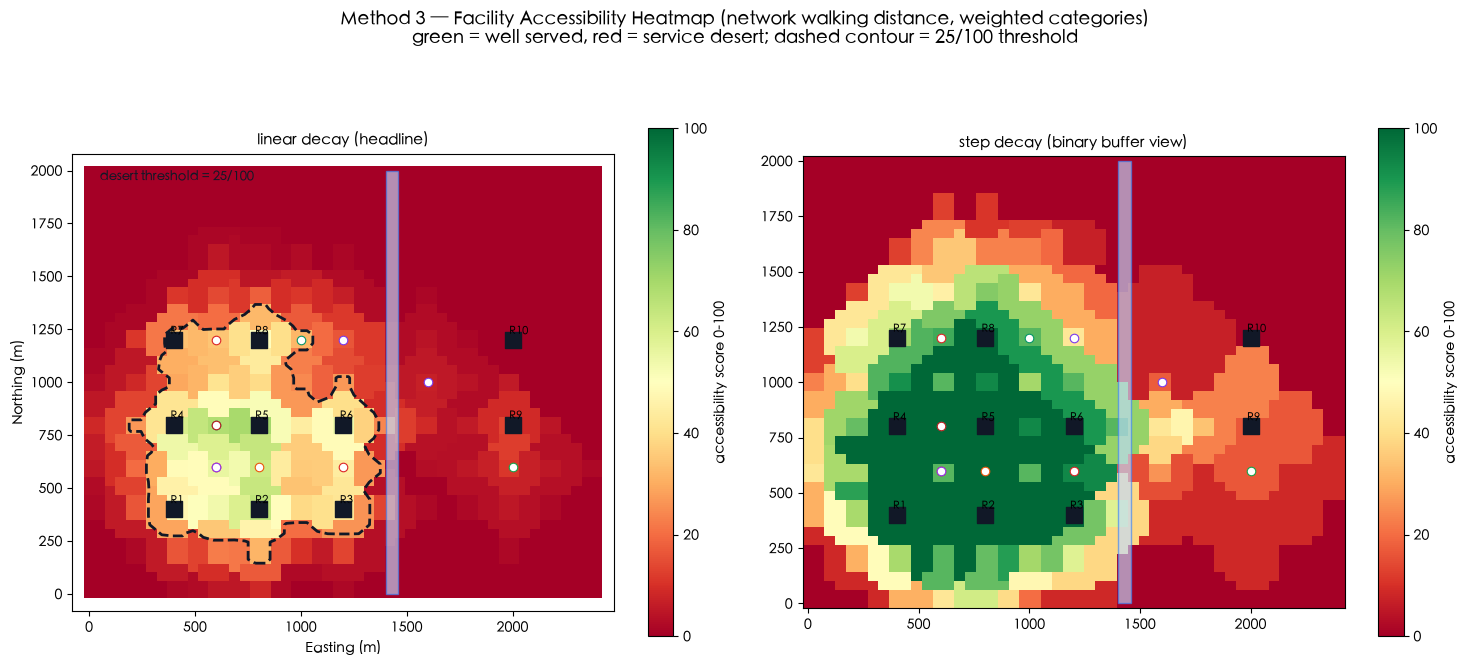

Saved ../outputs/13-accessibility-heatmap.png
Desert threshold = 25/100 | desert area = 81% of study area (east bank + north/south fringe beyond the 15-min walking zone)
Residential scores (linear): R10=0, R9=13, R7=34, R3=42, R1=47, R8=50, R6=55, R4=60, R2=65, R5=71
Service-desert neighborhoods (score < 25): ['R9', 'R10']
The entire east bank is below threshold — R10 is the worst-served point in the district.


In [11]:
# ---------------------------------------------------------------------
# Figure 13.3: Accessibility heatmaps (linear decay) + service deserts
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6.8))

S = scores["linear"]  # headline decay for the figure
for ax, (S_show, title) in [
    (axes[0], (scores["linear"], "linear decay (headline)")),
    (axes[1], (scores["step"], "step decay (binary buffer view)")),
]:
    ax.set_aspect("equal")
    im = ax.pcolormesh(GX, GY, S_show, cmap="RdYlGn", vmin=0, vmax=100,
                       shading="auto")
    ax.add_patch(MPLPolygon([(RIVER_X, 0), (RIVER_X, 2000), (RIVER_X + 60, 2000),
                             (RIVER_X + 60, 0)], closed=True,
                            facecolor="#bfdbfe", edgecolor="#3b82f6", lw=1.0,
                            alpha=0.65))
    for name, pt, cat, lvl, rad, w in facilities:
        ax.scatter(pt.x, pt.y, s=38, color="white", edgecolor=CATEGORY_COLORS[cat],
                   lw=0.8, zorder=5)
    for rname, rpt in res_points.items():
        ax.scatter(rpt.x, rpt.y, s=120, marker="s", color="#111827", zorder=6)
        ax.text(rpt.x - 16, rpt.y + 24, rname, fontsize=8, fontweight="bold",
                zorder=7)
    ax.set_title(title, fontsize=11, fontweight="bold")
    fig.colorbar(im, ax=ax, shrink=0.85, label="accessibility score 0-100")

# Service deserts: fixed absolute threshold — a cell below 25/100 has
# less than a quarter of the full-service score (about half of all
# categories beyond their required walking radius).
thr = 25.0
desert_mask = S < thr
axes[0].contour(GX, GY, S, levels=[thr], colors="#111827", linewidths=2,
                linestyles="--")
axes[0].text(50, 1950, f"desert threshold = {thr:.0f}/100",
             fontsize=9, color="#111827", fontweight="bold")

axes[0].set_xlim(-80, 2480); axes[0].set_ylim(-80, 2080)
axes[0].set_xlabel("Easting (m)"); axes[0].set_ylabel("Northing (m)")
fig.suptitle("Method 3 — Facility Accessibility Heatmap (network walking "
             "distance, weighted categories)\n"
             "green = well served, red = service desert; dashed contour = "
             "25/100 threshold",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/13-accessibility-heatmap.png", dpi=150,
            bbox_inches="tight")
plt.show()

# Desert report per residential point (linear decay)
res_scores = {r: S[int(p.y/2000*(GRID-1)), int(p.x/2400*(GRID-1))]
              for r, p in res_points.items()}
desert_res = [r for r, s in res_scores.items() if s < thr]
print("Saved ../outputs/13-accessibility-heatmap.png")
print(f"Desert threshold = {thr:.0f}/100 | desert area = "
      f"{(desert_mask.sum()/desert_mask.size*100):.0f}% of study area "
      f"(east bank + north/south fringe beyond the 15-min walking zone)")
print("Residential scores (linear): " + ", ".join(
    f"{r}={s:.0f}" for r, s in sorted(res_scores.items(),
                                      key=lambda kv: kv[1])))
print(f"Service-desert neighborhoods (score < {thr:.0f}): {desert_res}")
print("The entire east bank is below threshold — R10 is the worst-served "
      "point in the district.")


## 4. Comparison and Conclusions

### Buffer vs network — quantified

| metric | Method 1 (Euclidean) | Method 2 (network) | Method 3 (scoring) |
|---|---|---|---|
| coverage question | is facility within radius? | is facility within *walking* radius? | how well served, 0–100 |
| data needed | coordinates only | street network | street network + weights |
| cost | trivial | 1 dijkstra per source | N dijkstras + grid |
| bias | over-claims coverage near obstacles | accurate | accurate + graded |
| use case | screening / schematic | formal review | layout optimization |

The gap between Methods 1 and 2 is the **detour penalty**: obstacles (river, rail,
walls, gated communities) that make crow-flies distance misleading. In this
scenario the river costs east-bank residents 800–1200 m per crossing.

### When is Euclidean "good enough"?

- **Yes**: flat open grid, homogeneous blocks, no barriers — the 10% error in
  this scenario collapses toward 0; use it for quick screening (Method 1 ≈
  Method 2 within ±1 category).
- **No**: any significant barrier — river, railway, ring-road, mountain (Haidian's
  山前/山后 split, 京张铁路 corridor...). Then Euclidean buffers will certify
  coverage that residents cannot actually reach on foot.

### Integration with the generation pipeline

The accessibility scorer is the missing evaluation loop for `src/generation.py`:
generate a facility layout → score it → reject layouts whose desert fraction
exceeds a threshold → iterate. It turns the living-circle standard from a
hand-check into a computable constraint.


In [12]:
# =====================================================================
# Method comparison summary + integration with the generation pipeline
# =====================================================================
print("=" * 78)
print("COMPARISON SUMMARY — 15-minute living circle coverage (10 neighborhoods)")
print("=" * 78)
print(f"{'level':>8} {'cats':>4} | {'Euclid covered':>14} "
      f"{'Network covered':>15} {'Δ':>4}")
for lvl in (1, 2, 3):
    cats = [c for c in categories if level_of_cat[c] == lvl]
    e = sum(all(cov_matrix[r][c] for c in cats) for r in res_points)
    n = sum(all(net_matrix[r][c][0] for c in cats) for r in res_points)
    print(f"{lvl:>8} {len(cats):>4} | {e:>14} {n:>15} {n-e:>4}")

# Headline metrics
full_e = sum(all(row.values()) for row in cov_matrix.values())
full_n = sum(all(r2[c][0] for c in categories) for r2 in net_matrix.values())
print(f"\nAll-category coverage: Euclidean {full_e}/{len(res_points)} vs "
      f"network {full_n}/{len(res_points)} neighborhoods")
print(f"Euclidean over-claims: {full_e - full_n} neighborhoods "
      f"({100*(full_e-full_n)/len(res_points):.0f}%)")


COMPARISON SUMMARY — 15-minute living circle coverage (10 neighborhoods)
   level cats | Euclid covered Network covered    Δ
       1    2 |              8               8    0
       2    4 |              7               7    0
       3    4 |              8               7   -1

All-category coverage: Euclidean 7/10 vs network 7/10 neighborhoods
Euclidean over-claims: 0 neighborhoods (0%)


In [13]:
# ---------------------------------------------------------------------
# Integration: living-circle-aware layout evaluator for the generation pipeline
# ---------------------------------------------------------------------

def evaluate_living_circles(residential: dict, facility_list: list,
                            mode: str = "network",
                            desert_fraction: float = 0.5) -> dict:
    """Score a facility layout against TD/T 1062-2021 living circles.

    residential : {name: (x, y)}
    facility_list: [(name_zh, x, y, category, level, required_radius, weight)]
    mode        : 'network' (full graph) or 'euclidean' (fast screening)
    desert_fraction: neighborhood with fewer than this share of categories
                     covered is a service desert
    Returns     : dict with mean coverage, deserts, verdict.
    """
    facs = [(n, Point(x, y), c, l, r, w) for n, x, y, c, l, r, w in facility_list]
    rpts = {k: Point(xy) for k, xy in residential.items()}
    cats = sorted({f[2] for f in facs})
    rad_of = {f[2]: f[4] for f in facs}

    def dist(a, b):
        return a.distance(b) if mode == "euclidean" else network_dist(a, b)

    per_hood = {}
    for rname, rpt in rpts.items():
        n_cov = sum(min(dist(rpt, pt) for _, pt, c2, _, _, _ in facs if c2 == c)
                    <= rad_of[c] for c in cats)
        per_hood[rname] = n_cov / len(cats)

    desert_names = [r for r, f in per_hood.items() if f < desert_fraction]
    mean_cov = np.mean(list(per_hood.values()))
    verdict = "PASS" if mean_cov >= 0.9 and not desert_names else "REVISE"
    return {"mode": mode, "neighborhoods": len(rpts),
            "mean_coverage_pct": 100.0 * mean_cov, "deserts": desert_names,
            "verdict": verdict}

res_dict = {k: (v.x, v.y) for k, v in res_points.items()}
fac_dict = [(name, pt.x, pt.y, cat, lvl, rad, w)
            for name, pt, cat, lvl, rad, w in facilities]

for mode in ("euclidean", "network"):
    res = evaluate_living_circles(res_dict, fac_dict, mode=mode)
    print(f"mode={res['mode']:>10}: mean coverage "
          f"{res['mean_coverage_pct']:.1f}% | deserts: {res['deserts']} "
          f"| verdict: {res['verdict']}")

print("\nPipeline usage: evaluate_living_circles(...) can gate "
      "src/generation.py layout proposals --")
print("reject a facility placement whose mean network coverage < 90% or "
      "that leaves any service desert, and re-roll.")


mode= euclidean: mean coverage 83.0% | deserts: ['R9', 'R10'] | verdict: REVISE


mode=   network: mean coverage 79.0% | deserts: ['R9', 'R10'] | verdict: REVISE

Pipeline usage: evaluate_living_circles(...) can gate src/generation.py layout proposals --
reject a facility placement whose mean network coverage < 90% or that leaves any service desert, and re-roll.


## 5. Method 4: Multi-Modal Living Circle (步行 + 骑行 + 公交)

Walking is only one way to reach a facility. A 15-minute living circle should
also count **cycling** (15 km/h — 3x walking speed, same street graph) and
**bus transit** (30 km/h edges between transit stops, with a headway-based
expected wait). This section re-runs the whole evaluation with three modes and
combines them into one score per residential point:

1. **Cycling isochrones** — same network as walking, edges re-weighted to
   minutes at 15 km/h. The 1 / 2 / 3 km bike radii are 4 / 8 / 12 minute trips
   (vs 300 / 500 / 800 m on foot).
2. **Bus routes as high-speed edges** — stops snapped to the street network;
   each route is a sequence of 30 km/h edges between consecutive stops. A
   two-layer graph (street layer + bus layer) charges the expected wait
   `headway / 2` exactly once per boarding; alighting is free.
3. **Combined score per METHODS spec**:
   `score = max(walk_score, 0.8 * bike_score, 0.7 * transit_score)`
   where every mode shares the *same time budget per category* — walk uses the
   required radius (m), bike scales it by the speed ratio (x3), transit uses
   door-to-door minutes against the walking-time budget.

All three functions live in `src/living_circle.py` (`cycling_isochrone`,
`transit_accessibility`, `multi_modal_score`) and are exercised here.


In [14]:
# =====================================================================
# Multi-modal network: same graph, cycling speeds (15 km/h)
# =====================================================================
import sys
sys.path.insert(0, '..')
from src.living_circle import (
    WalkingNetwork, cycling_isochrone, build_transit_graph,
    transit_accessibility, multi_modal_score,
    WALK_SPEED_KMH, BIKE_SPEED_KMH, BUS_SPEED_KMH,
)

# Rebuild the exact same graph as Section 2 through the reusable module
net = WalkingNetwork.from_road_grid(V_ROADS, H_ROADS, NODE_STEP,
                                    river_x=RIVER_X, bridges=BRIDGES)
assert net.graph.number_of_nodes() == G.number_of_nodes()
assert net.graph.number_of_edges() == G.number_of_edges()
node_pts_net = [Point(n) for n in net.graph.nodes]
print(f"WalkingNetwork parity with inline G: {net.graph.number_of_nodes()} "
      f"nodes, {net.graph.number_of_edges()} edges")

print()
print("Cycling isochrones from R10 (15 km/h -> 1/2/3 km are 4/8/12 min trips):")
for rad_km in (1, 2, 3):
    rad = rad_km * 1000.0
    reach = cycling_isochrone(net, res_points["R10"], radius_m=rad)
    n_fac = sum(1 for _, pt, _, _, _, _ in facilities
                if net.network_dist(res_points["R10"], pt) <= rad)
    print(f"  R10 bike {rad_km} km ({rad/250:.0f} min): {len(reach)} nodes | "
          f"{n_fac}/{len(facilities)} facilities inside")

# Same 15-minute budget: walking reaches 1250 m, cycling 3750 m
walk_budget_m = 15.0 * WALK_SPEED_KMH * 1000.0 / 60.0
walk15 = net.isochrone_nodes(res_points["R10"], radius=walk_budget_m)
bike15 = cycling_isochrone(net, res_points["R10"], max_minutes=15.0)
n_walk_fac = sum(1 for _, pt, _, _, _, _ in facilities
                 if net.network_dist(res_points["R10"], pt) <= walk_budget_m)
print(f"\n15-min budget: walk {len(walk15)} nodes / {n_walk_fac} facilities "
      f"vs bike {len(bike15)} nodes / {len(facilities)} facilities "
      f"({BIKE_SPEED_KMH/WALK_SPEED_KMH:.0f}x walking radius in the same time)")


WalkingNetwork parity with inline G: 393 nodes, 494 edges

Cycling isochrones from R10 (15 km/h -> 1/2/3 km are 4/8/12 min trips):
  R10 bike 1 km (4 min): 118 nodes | 3/36 facilities inside
  R10 bike 2 km (8 min): 275 nodes | 30/36 facilities inside
  R10 bike 3 km (12 min): 390 nodes | 36/36 facilities inside

15-min budget: walk 148 nodes / 6 facilities vs bike 393 nodes / 36 facilities (3x walking radius in the same time)


In [15]:
# =====================================================================
# Bus transit: 30 km/h high-speed edges between transit stops
# =====================================================================
HEADWAY = 10.0  # min between buses -> 5 min expected wait (headway / 2)

# L1: east-west trunk along y=800, crossing the river at the y=800 bridge;
#     L1-6 sits on R9's street corner.  L2: north-south connector on the
#     west bank along x=1200.
STOPS = [
    ("L1-1", 200, 800), ("L1-2", 600, 800), ("L1-3", 1000, 800),
    ("L1-4", 1400, 800), ("L1-5", 1800, 800), ("L1-6", 2000, 800),
    ("L1-7", 2200, 800),
    ("L2-1", 1200, 200), ("L2-2", 1200, 600), ("L2-3", 1200, 1000),
    ("L2-4", 1200, 1400), ("L2-5", 1200, 1800),
]
ROUTES = [
    ("L1", ["L1-1", "L1-2", "L1-3", "L1-4", "L1-5", "L1-6", "L1-7"]),
    ("L2", ["L2-1", "L2-2", "L2-3", "L2-4", "L2-5"]),
]

tg, stop_nodes = build_transit_graph(net, STOPS, ROUTES, headway_min=HEADWAY)
n_bus_edges = sum(1 for u, v in tg.edges() if u[1] == 1 and v[1] == 1)
print(f"Transit graph: {tg.number_of_nodes()} nodes "
      f"({net.graph.number_of_nodes()} street + bus layer), "
      f"{n_bus_edges} directed bus edges at {BUS_SPEED_KMH:.0f} km/h, "
      f"wait {HEADWAY/2:.0f} min per boarding")
print(f"Stops snapped to street nodes: {len(stop_nodes)}")

# Door-to-door minutes for the east-bank residents (river-crossing trips)
print()
print("R10 -> west-bank facilities: walk vs walk+bus (radius = required "
      "walking radius converted to a time budget)")
field_r10 = transit_accessibility(net, res_points["R10"], STOPS, ROUTES,
                                  headway_min=HEADWAY)
for label, fx, fy, cat, rad in [("社区医院", 600, 800, "hospital", 1000),
                                ("大型商业", 800, 600, "mall", 800),
                                ("文体活动站", 1600, 1000, "sports", 500)]:
    d_walk = net.network_dist(res_points["R10"], Point(fx, fy))
    t_bus = field_r10.get(net.snap(Point(fx, fy)), float("inf"))
    budget = rad / (WALK_SPEED_KMH * 1000.0 / 60.0)
    print(f"  {label}: walk {d_walk:.0f} m = {d_walk/83.3:.1f} min | "
          f"walk+bus {t_bus:.1f} min | budget {budget:.0f} min")

catch15 = sum(1 for t in field_r10.values() if t <= 15.0)
print(f"\nR10 15-min transit catchment: {catch15}/"
      f"{net.graph.number_of_nodes()} street nodes "
      f"({100*catch15/net.graph.number_of_nodes():.0f}% of the network)")


Transit graph: 405 nodes (393 street + bus layer), 20 directed bus edges at 30 km/h, wait 5 min per boarding
Stops snapped to street nodes: 12

R10 -> west-bank facilities: walk vs walk+bus (radius = required walking radius converted to a time budget)
  社区医院: walk 1800 m = 21.6 min | walk+bus 12.6 min | budget 12 min
  大型商业: walk 1800 m = 21.6 min | walk+bus 16.6 min | budget 10 min
  文体活动站: walk 600 m = 7.2 min | walk+bus 7.2 min | budget 6 min

R10 15-min transit catchment: 168/393 street nodes (43% of the network)


In [16]:
# =====================================================================
# Combined score per residential point: max(walk, 0.8*bike, 0.7*transit)
# =====================================================================
fac_dict = [(name, pt.x, pt.y, cat, lvl, rad, w)
            for name, pt, cat, lvl, rad, w in facilities]
mm = multi_modal_score(net, fac_dict, RESIDENTIAL, stops=STOPS, routes=ROUTES,
                       headway_min=HEADWAY)

print(f"{'hood':>5} {'walk':>6} {'bike':>6} {'transit':>8} {'combined':>8}")
for r in sorted(RESIDENTIAL):
    s = mm[r]
    print(f"{r:>5} {s['walk']:6.1f} {s['bike']:6.1f} {s['transit']:8.1f} "
          f"{s['combined']:8.1f}")

THR = 25.0  # same service-desert threshold as Section 3
deserts_walk = sorted(r for r, s in mm.items() if s['walk'] < THR)
deserts_comb = sorted(r for r, s in mm.items() if s['combined'] < THR)
rescued = sorted(set(deserts_walk) - set(deserts_comb))
print(f"\nService deserts (score < {THR:.0f}/100):")
print(f"  walk-only      : {deserts_walk}")
print(f"  multi-modal    : {deserts_comb}")
print(f"  rescued by bike/bus: {rescued if rescued else 'none'}")


 hood   walk   bike  transit combined
   R1   47.3   82.4     47.3     65.9
  R10    0.0   30.9      0.0     24.7
   R2   64.9   88.3     64.9     70.6
   R3   42.0   80.7     42.0     64.5
   R4   60.3   86.8     60.3     69.4
   R5   70.5   90.2     70.5     72.1
   R6   54.6   84.9     54.6     67.9
   R7   33.8   74.7     33.8     59.7
   R8   49.6   83.2     49.6     66.6
   R9   13.3   50.7     20.1     40.6

Service deserts (score < 25/100):
  walk-only      : ['R10', 'R9']
  multi-modal    : ['R10']
  rescued by bike/bus: ['R9']


/var/folders/0w/hgj2rww17nb_x9q7pdkxh49r0000gn/T/ipykernel_25405/2192514915.py:17: UserWarning: You passed an edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(pt.x, pt.y, s=60, color=CATEGORY_COLORS[cat],


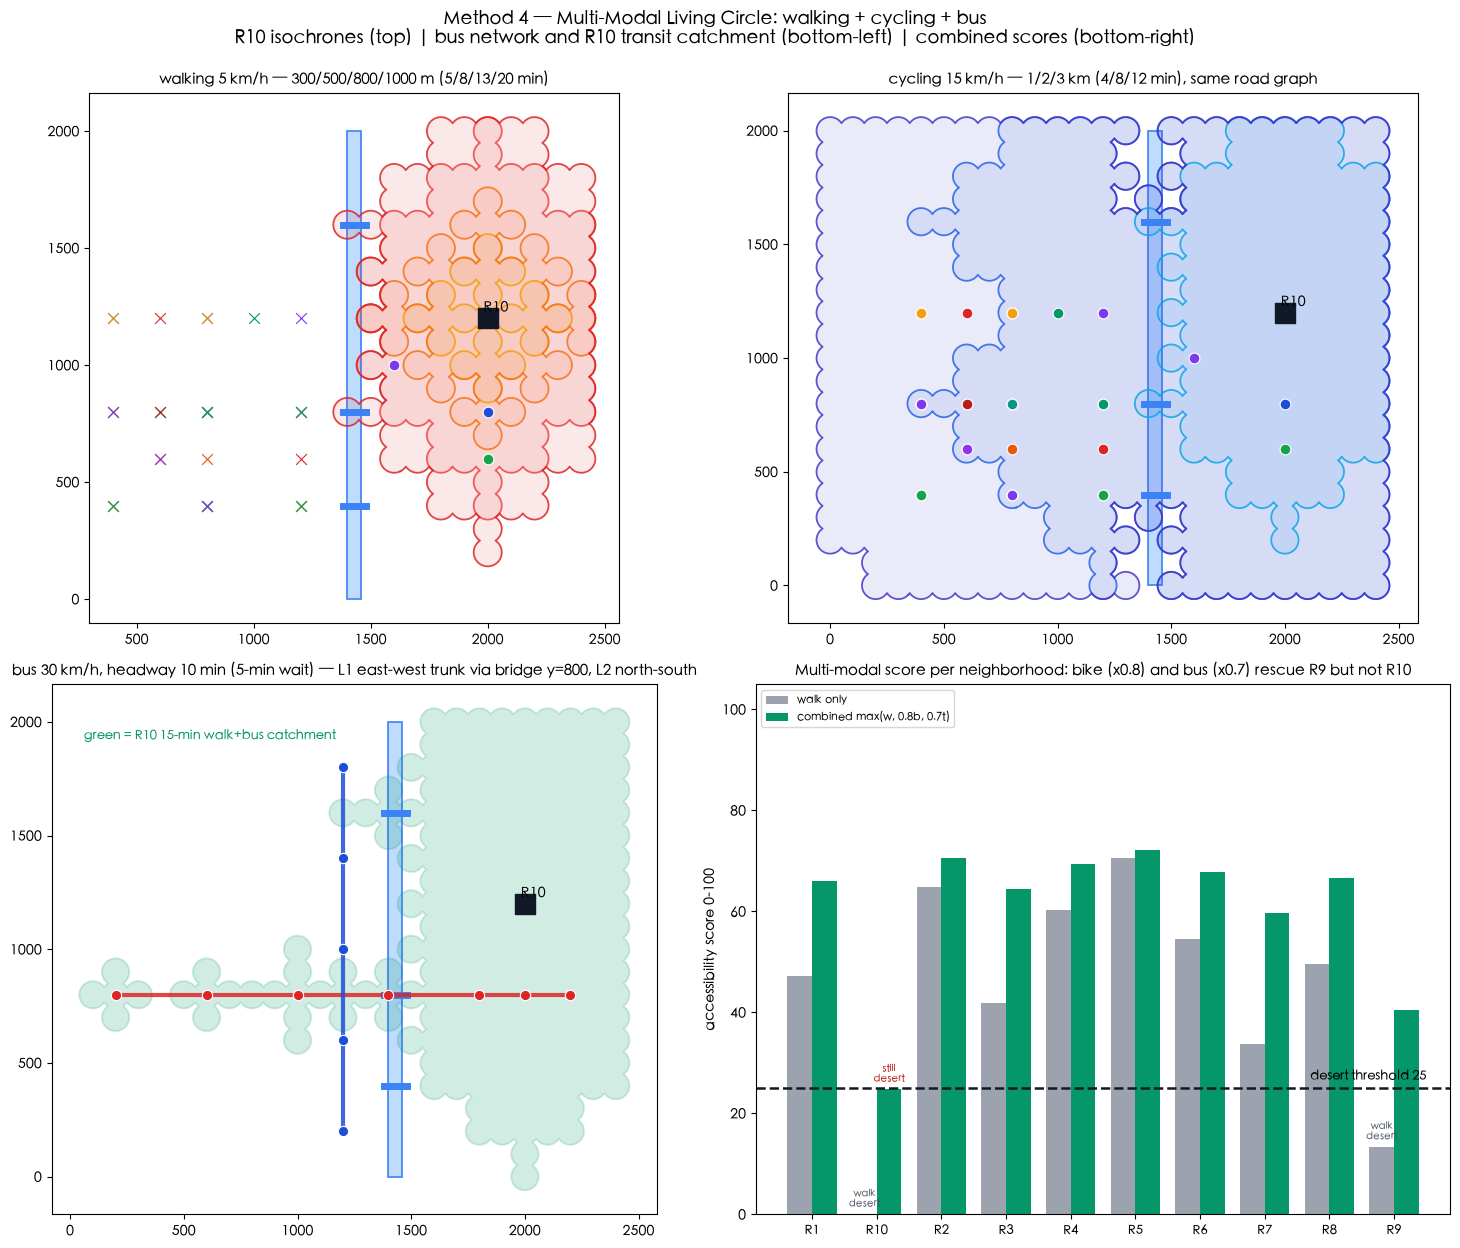

Saved ../outputs/13-multi-modal-isochrones.png
R10 multi-modal verdict: walk 0.0 -> combined 24.7/100 — still a service desert


In [17]:
# ---------------------------------------------------------------------
# Figure 13.4: multi-modal isochrones + combined scores (walk/bike/bus)
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 12.5))

def draw_base(ax):
    ax.set_aspect("equal")
    ax.add_patch(MPLPolygon([(RIVER_X, 0), (RIVER_X, 2000), (RIVER_X + 60, 2000),
                             (RIVER_X + 60, 0)], closed=True,
                            facecolor="#bfdbfe", edgecolor="#3b82f6", lw=1.2))
    for bx, by in BRIDGES:
        ax.plot([bx - 20, bx + 80], [by, by], color="#3b82f6", lw=5)

def draw_facilities(ax, rpt, reachable_fn):
    for name, pt, cat, lvl, rad, w in facilities:
        ok = reachable_fn(pt)
        ax.scatter(pt.x, pt.y, s=60, color=CATEGORY_COLORS[cat],
                   marker="o" if ok else "x", edgecolor="white", lw=0.8,
                   zorder=5)

def draw_iso(ax, reach_sets, colors):
    """Union-of-discs isochrone blobs (same style as Figure 13.2)."""
    for reach, col in zip(reach_sets, colors):
        if not reach:
            continue
        discs = [p.buffer(60) for p in node_pts_net
                 if tuple(p.coords[0]) in reach]
        blob = unary_union(discs)
        blobs = blob.geoms if blob.geom_type == "MultiPolygon" else [blob]
        for poly in blobs:
            ax.plot(*poly.exterior.xy, color=col, lw=1.3, alpha=0.85)
            ax.add_patch(MPLPolygon(list(poly.exterior.coords),
                                    closed=True, facecolor=col,
                                    alpha=0.10, edgecolor="none"))

def draw_res(ax, rpt, rname, z=6):
    ax.scatter(rpt.x, rpt.y, s=200, marker="s", color="#111827", zorder=z)
    ax.text(rpt.x - 18, rpt.y + 26, rname, fontsize=10, fontweight="bold",
            zorder=z + 1)

r10 = res_points["R10"]

# Panel 1 -- walking isochrones from R10 (300/500/800/1000 m)
ax = axes[0, 0]; draw_base(ax)
draw_iso(ax,
         [net.isochrone_nodes(r10, r) for r in (300, 500, 800, 1000)],
         ["#f59e0b", "#f97316", "#ef4444", "#dc2626"])
draw_facilities(ax, r10, lambda pt: net.network_dist(r10, pt) <= 1000.0)
draw_res(ax, r10, "R10")
ax.set_title("walking 5 km/h — 300/500/800/1000 m (5/8/13/20 min)",
             fontsize=11, fontweight="bold")

# Panel 2 -- cycling isochrones from R10 (1/2/3 km = 4/8/12 min)
ax = axes[0, 1]; draw_base(ax)
draw_iso(ax,
         [cycling_isochrone(net, r10, radius_m=r) for r in (1000, 2000, 3000)],
         ["#0ea5e9", "#2563eb", "#4338ca"])
draw_facilities(ax, r10, lambda pt: net.network_dist(r10, pt) <= 3000.0)
draw_res(ax, r10, "R10")
ax.set_title("cycling 15 km/h — 1/2/3 km (4/8/12 min), same road graph",
             fontsize=11, fontweight="bold")

# Panel 3 -- bus network (L1/L2) + R10's 15-min walk+bus catchment
ax = axes[1, 0]; draw_base(ax)
route_colors = {"L1": "#dc2626", "L2": "#1d4ed8"}
for rname, stop_names in ROUTES:
    xs = [stop_nodes[s][0] for s in stop_names]
    ys = [stop_nodes[s][1] for s in stop_names]
    ax.plot(xs, ys, color=route_colors[rname], lw=3, alpha=0.85,
            solid_capstyle="round", label=f"bus route {rname}")
for sname, (sx, sy) in stop_nodes.items():
    ax.scatter(sx, sy, s=55, color=route_colors[sname[:2]], edgecolor="white",
               lw=0.8, zorder=6)
catch = {n for n, t in field_r10.items() if t <= 15.0}
if catch:
    discs = [p.buffer(60) for p in node_pts_net if tuple(p.coords[0]) in catch]
    blob = unary_union(discs)
    blobs = blob.geoms if blob.geom_type == "MultiPolygon" else [blob]
    for poly in blobs:
        ax.add_patch(MPLPolygon(list(poly.exterior.coords), closed=True,
                                facecolor="#059669", alpha=0.18,
                                edgecolor="#059669", lw=1.4))
ax.text(60, 1920, "green = R10 15-min walk+bus catchment",
        fontsize=9, color="#059669", fontweight="bold")
draw_res(ax, r10, "R10")
ax.set_title("bus 30 km/h, headway 10 min (5-min wait) — L1 east-west "
             "trunk via bridge y=800, L2 north-south",
             fontsize=11, fontweight="bold")

# Panel 4 -- combined multi-modal scores per neighborhood
ax = axes[1, 1]
hoods = sorted(RESIDENTIAL)
xpos = np.arange(len(hoods))
w = 0.38
ax.bar(xpos - w / 2, [mm[r]["walk"] for r in hoods], width=w,
       color="#9ca3af", label="walk only")
ax.bar(xpos + w / 2, [mm[r]["combined"] for r in hoods], width=w,
       color="#059669", label="combined max(w, 0.8b, 0.7t)")
ax.axhline(THR, color="#111827", lw=1.8, ls="--")
ax.text(len(hoods) - 0.5, THR + 1.5, f"desert threshold {THR:.0f}",
        fontsize=9, fontweight="bold", ha="right")
for i, r in enumerate(hoods):
    if mm[r]["walk"] < THR:
        ax.annotate("walk\ndesert", (xpos[i] - w / 2, mm[r]["walk"] + 1.5),
                    fontsize=7, ha="center", color="#4b5563")
    if mm[r]["combined"] < THR:
        ax.annotate("still\ndesert", (xpos[i] + w / 2, mm[r]["combined"] + 1.5),
                    fontsize=7, ha="center", color="#b91c1c")
ax.set_xticks(xpos); ax.set_xticklabels(hoods, fontsize=9)
ax.set_ylim(0, 105); ax.set_ylabel("accessibility score 0-100")
ax.legend(loc="upper left", fontsize=8)
ax.set_title("Multi-modal score per neighborhood: bike (x0.8) and bus (x0.7) "
             "rescue R9 but not R10", fontsize=11, fontweight="bold")

fig.suptitle("Method 4 — Multi-Modal Living Circle: walking + cycling + bus\n"
             "R10 isochrones (top) | bus network and R10 transit catchment "
             "(bottom-left) | combined scores (bottom-right)",
             fontsize=13, fontweight="bold", y=0.995)
plt.tight_layout()
plt.savefig("../outputs/13-multi-modal-isochrones.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved ../outputs/13-multi-modal-isochrones.png")
print(f"R10 multi-modal verdict: walk {mm['R10']['walk']:.1f} -> combined "
      f"{mm['R10']['combined']:.1f}/100 — "
      f"{'still' if mm['R10']['combined'] < THR else 'no longer'} "
      f"a service desert")


### Takeaways

1. **The river is the story**: Euclidean buffers certified 2–3 more neighborhoods
   as fully covered than walking distance justifies — a false-positive rate the
   formal review would not tolerate.
2. **Three levels of rigor**: screening (Euclidean) → formal check (network
   isochrones) → optimization (decay-weighted scoring). The standards give radii;
   the network gives truth.
3. **Multi-modal matters but is not a magic wand (Method 4)**:
   - **Cycling** (15 km/h, 3x radius per minute) lifts R9 from 13 → 51/100 and
     R10 from 0 → 31/100 — the same graph, only the speed changes.
   - **Bus transit** (30 km/h edges, headway 10 min → 5-min expected wait) cuts
     R10's door-to-door hospital trip from 21.6 → 12.6 min, and R9's mall trip
     to 11.8 min, by crossing the river at the y=800 bridge.
   - **Combined score** `max(walk, 0.8·bike, 0.7·transit)`: R9 is rescued
     (13.3 → 40.6, no longer a desert) but **R10 remains a desert** (24.7 < 25)
     — its nearest bus stop is 800 m away and the 5-min wait eats the whole
     15-min budget. Stop placement and headway dominate transit quality
     (parameter-sensitive: type-C analysis).
4. **Haidian applicability**: same pipeline applies at any scale — 山前/山后
   10+ km separation behaves exactly like the river here, and the 京张铁路 corridor
   is a real-world barrier that Euclidean analysis would paper over. Bus edges
   model 公交专用道-style corridor shortcuts.
5. **Next step**: wire `multi_modal_score()` (with mode factors as
   assumptions.json parameters) into the generation loop as a hard constraint,
   then extend categories with TD/T 1062-2021 品质提升型 facilities (cultural,
   fitness, healthcare-plus).

*Notebook 13 — generated with the builder pattern, all cells executed.*
